# Data Exploration and Transformation
This section loads, explores and transforms the data for use in the training of the CNN

The initial cell aims to load the data from your google drive. If you followed the code sheet then you can continue to execute the cells in order. However if the data has not yet been plaecd in the correct Google Drive folder please execute the following steps:

1. Navigate to https://kaggle.com/datasets/a7372f357af9e3faaaf8df6b83e94cd0664a081fe912e782c217a100e03d7a95
2. Download the dataset 3GB in size containing 2 zip files titled Sick_Fish and Healthy_fish.
3. Place the zip files in your own Google drive under the directory structure: /content/gdrive/MyDrive/"Tilapia data"/

When executing this code to train any models ensure that the runtime resources are set to: V100 + High-Ram

In [ ]:
# Connecting to Gdrive for the data
from google.colab import drive
drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


In [ ]:
# Force the use of GPU if available

import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


In [ ]:
# Unzip the Sick and Healthy Nile Tilapia dataset and suppress the output
# Data is available in the drive under their respective zip name folders

!unzip /content/gdrive/MyDrive/"Tilapia data"/Sick_Fish.zip > /dev/null
!unzip /content/gdrive/MyDrive/"Tilapia data"/Healthy_Fish.zip > /dev/null

Image size = (2560, 1440)


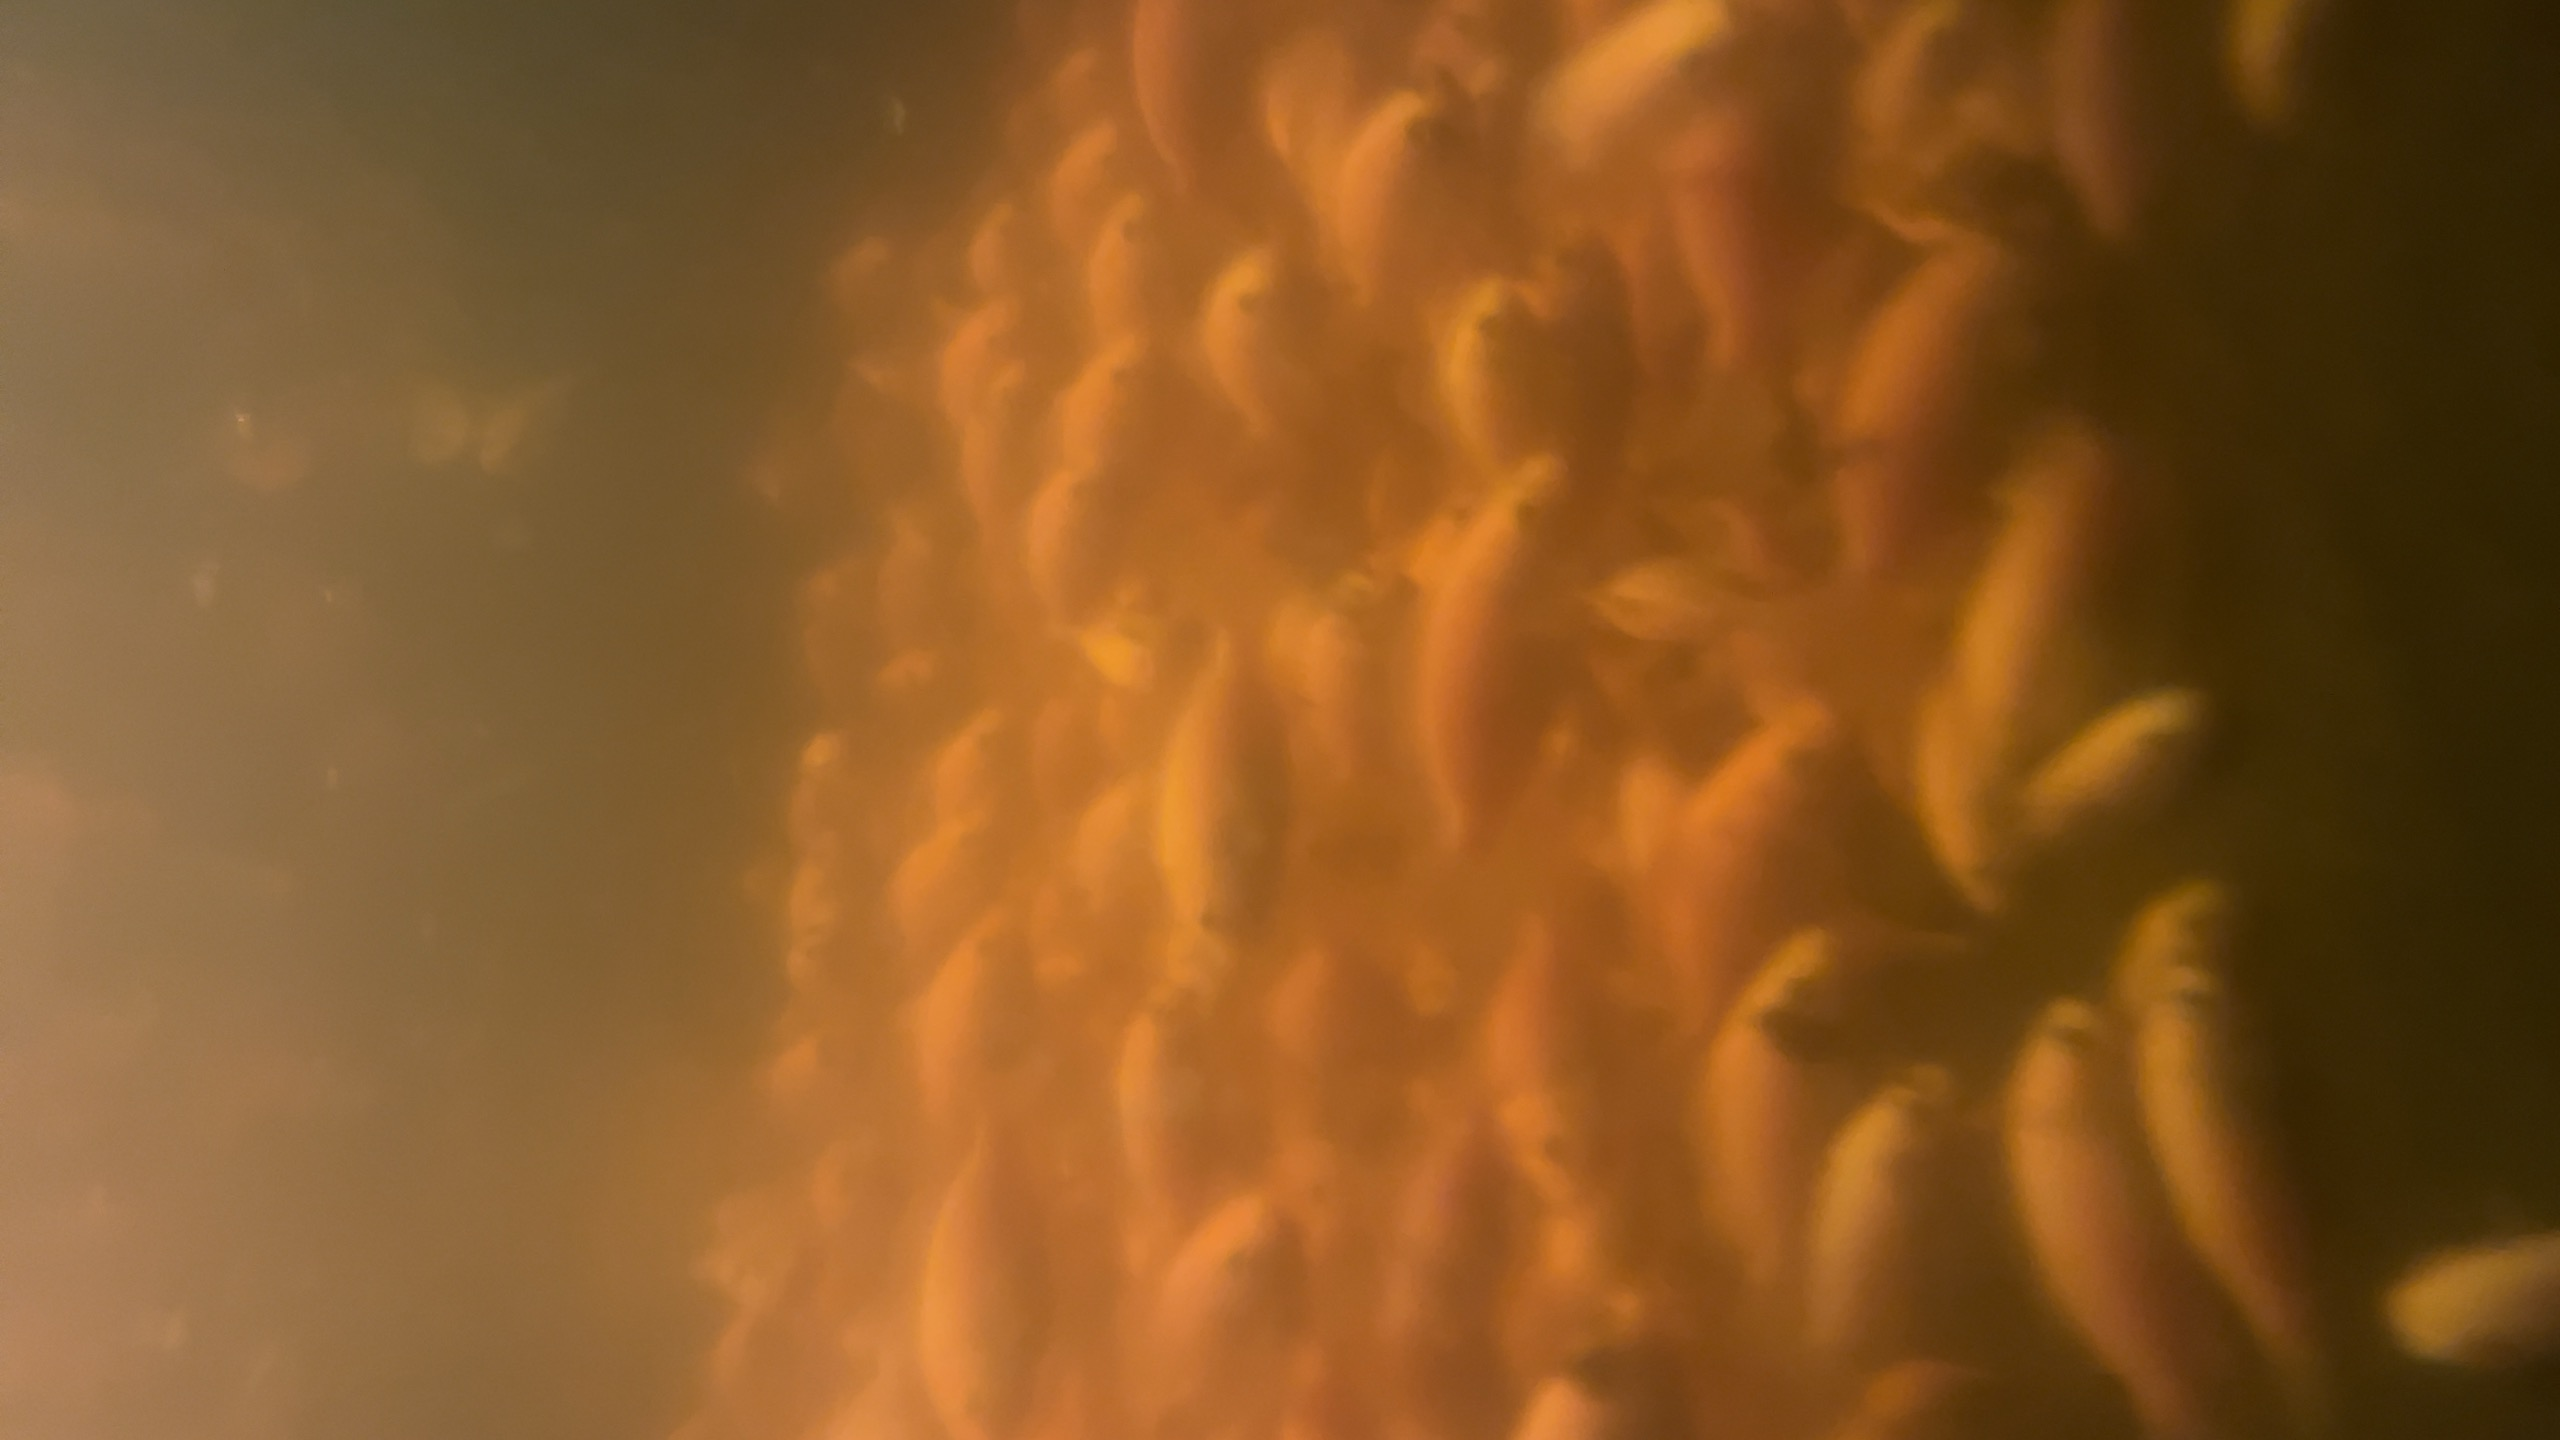

In [ ]:
# Print a single image from the dataset to ensure correct loading

import tensorflow as tf
img = tf.keras.preprocessing.image.load_img('/content/Healthy_Fish/IMG_000024_healthy_2000_9_score.jpg')
print("Image size = " + str(img.size))
img

In [ ]:
# Data exploration using pandas and numpy to determine the range of sizes of images in our dataset
import pandas as pd
import numpy as np
import os

# Healthy fish image size exploration
folder_healthy = '/content/Healthy_Fish'
image_sizes_healthy = []

for image in os.listdir(folder_healthy):
  image_path = 'Healthy_Fish/' + image
  fish_image = tf.keras.preprocessing.image.load_img(image_path)
  image_sizes_healthy.append(fish_image.size)

# Sick fish image size exploration
folder_sick  = '/content/Sick_Fish'
image_sizes_sick = []

for image in os.listdir(folder_sick):
  image_path = 'Sick_Fish/' + image
  fish_image = tf.keras.preprocessing.image.load_img(image_path)
  image_sizes_sick.append(fish_image.size)


#  Printing of the range of image sizes
unique_values_healthy_size = list(set(image_sizes_healthy))
print("Healthy fish sizes include: " )
print(unique_values_healthy_size)

unique_values_sick_size = list(set(image_sizes_sick))
print("Sick fish sizes include: " )
print(unique_values_sick_size)

Healthy fish sizes include: 
[(1920, 1080), (2560, 1440)]
Sick fish sizes include: 
[(1920, 1080), (2560, 1440)]


In [ ]:
# Count the number of files in both the healthy and sick dataset
num_files = len([f for f in os.listdir(folder_healthy)if os.path.isfile(os.path.join(folder_healthy, f))])
print("num of files in Healthy_Fish/: %d" % (num_files))

num_files = len([f for f in os.listdir(folder_sick)if os.path.isfile(os.path.join(folder_sick, f))])
print("num of files in Sick_Fish/: %d" % (num_files))

num of files in Healthy_Fish/: 3163
num of files in Sick_Fish/: 7566


## Resolution alterations

In the below section we execute code to ensure all images are of the same resolution. As both image sizes are of factor 1.78 we can easily scale down the higher resolution of 2560 by 1440 to 1120 by 630.

In [ ]:
# Setting height and width variables used in the rest of the notebook
height_picture = 1120
width_picture = 630

# Different image sizes fitting the factor 1.78 for testing purposes
#640 x 360
#800 x 450
#1280 x 720
# 1120 x 630
# 1920 x 1080



Resizing images and saving them back into the datasets

In [ ]:
import cv2

def resize_image(image_path, new_width, new_height):
    image = cv2.imread(image_path)
    if image is None:
        return
    resized_image = cv2.resize(image, (new_width, new_height))
    cv2.imwrite(image_path, resized_image)

def get_image_size(image_path):
    image = cv2.imread(image_path)
    if image is None:
        return None
    return image.shape[1], image.shape[0]  # image width, image height

folders = ["/content/Healthy_Fish", "/content/Sick_Fish"]
new_height, new_width = height_picture, width_picture

# Iterate through both fish folders and set the new height and width for each picture
# Logic also checks pictures are not the new size already. If they are, don't transform
for folder in folders:
    folder_path = folder
    for filename in os.listdir(folder_path):
        image_path = os.path.join(folder_path, filename)
        if os.path.isfile(image_path):
            width, height = get_image_size(image_path)
            if width != new_width or height != new_height:
                resize_image(image_path, new_width, new_height)

Iterate through the dataset to check there are no outliers from the expected size set earlier

In [ ]:
# Healthy fish image size exploration
folder_healthy = '/content/Healthy_Fish'
image_sizes_healthy_resize = []

for image in os.listdir(folder_healthy):
  image_path = 'Healthy_Fish/' + image
  fish_image = tf.keras.preprocessing.image.load_img(image_path)
  image_sizes_healthy_resize.append(fish_image.size)

# Sick fish image size exploration
folder_sick  = '/content/Sick_Fish'
image_sizes_sick_resize = []

for image in os.listdir(folder_sick):
  image_path = 'Sick_Fish/' + image
  fish_image = tf.keras.preprocessing.image.load_img(image_path)
  image_sizes_sick_resize.append(fish_image.size)


# Showcasing the range of image sizes in the data sets
unique_values_healthy_size_resize = list(set(image_sizes_healthy_resize))
print("Healthy fish sizes include: " )
print(unique_values_healthy_size_resize)

unique_values_sick_size_resize = list(set(image_sizes_sick_resize))
print("Sick fish sizes include: " )
print(unique_values_sick_size_resize)

Healthy fish sizes include: 
[(630, 1120)]
Sick fish sizes include: 
[(630, 1120)]


#Training, validation and test data

The below code focuses on creating new directories for the training, validation and test data in the ratio of 60, 25, 15 split. The images are first randomly shuffled before being split.

In [ ]:
import random
import shutil

# Initial directory path for healthy dataset
directory = '/content/Healthy_Fish'

# Output directories for training, validation, and testing data
train_dir = 'train_Healthy'
val_dir = 'validation_Healthy'
test_dir = 'test_Healthy'

# Output directories created if they don't already exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Get a list of all image files in the directory
image_files = [file for file in os.listdir(directory)]

# Shuffle the created list of images
random.shuffle(image_files)

# Calculate the number of images for each split
total_images = len(image_files)
train_split = int(0.6 * total_images)
val_split = int(0.25 * total_images)

# Split the images into training, validation, and testing sets
train_files = image_files[:train_split]
val_files = image_files[train_split:train_split + val_split]
test_files = image_files[train_split + val_split:]

# Move the files to their appropriate new directories
for file in train_files:
    shutil.move(os.path.join(directory, file), os.path.join(train_dir, file))

for file in val_files:
    shutil.move(os.path.join(directory, file), os.path.join(val_dir, file))

for file in test_files:
    shutil.move(os.path.join(directory, file), os.path.join(test_dir, file))

print("Data split successfully!")

Data split successfully!


Code below is the same as above but for the sick fish data. Except here the data split is 80, 13.7 and 6.3 due to the size difference in the datasets

In [ ]:
# Set the directory path
directory = '/content/Sick_Fish'

# Set the output directories for training, validation, and testing
train_dir = 'train_Sick'
val_dir = 'validation_Sick'
test_dir = 'test_Sick'

# Create the output directories if they don't exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Get a list of all image files in the directory
image_files_sick = [file for file in os.listdir(directory)]

# Shuffle the list of image files
random.shuffle(image_files_sick)

# Calculate the number of images for each split
total_images_sick = len(image_files_sick)
train_split_sick = int(0.8 * total_images_sick)
val_split_sick = int(0.137272 * total_images_sick)

# Split the images into training, validation, and testing sets
train_files = image_files_sick[:train_split_sick]
val_files = image_files_sick[train_split_sick:train_split_sick + val_split_sick]
test_files = image_files_sick[train_split_sick + val_split_sick:]

# Move the files to the appropriate directories
for file in train_files:
    shutil.move(os.path.join(directory, file), os.path.join(train_dir, file))

for file in val_files:
    shutil.move(os.path.join(directory, file), os.path.join(val_dir, file))

for file in test_files:
    shutil.move(os.path.join(directory, file), os.path.join(test_dir, file))

print("Data split successfully!")

Data split successfully!


In [ ]:
# Count the number of files in both the healthy and sick datasets of training, testing and validation
folder_test_healthy = '/content/test_Healthy'
folder_validation_healthy = '/content/validation_Healthy'
folder_train_healthy = '/content/train_Healthy'

folder_test_sick = '/content/test_Sick'
folder_validation_sick = '/content/validation_Sick'
folder_train_sick = '/content/train_Sick'


num_files = len([f for f in os.listdir(folder_test_healthy)if os.path.isfile(os.path.join(folder_test_healthy, f))])
print("num of files in test_Healthy/: %d" % (num_files))
num_files = len([f for f in os.listdir(folder_validation_healthy)if os.path.isfile(os.path.join(folder_validation_healthy, f))])
print("num of files in validation_Healthy/: %d" % (num_files))
num_files = len([f for f in os.listdir(folder_train_healthy)if os.path.isfile(os.path.join(folder_train_healthy, f))])
print("num of files in train_Healthy/: %d" % (num_files))

num_files = len([f for f in os.listdir(folder_test_sick)if os.path.isfile(os.path.join(folder_test_sick, f))])
print("num of files in test_Sick/: %d" % (num_files))
num_files = len([f for f in os.listdir(folder_validation_sick)if os.path.isfile(os.path.join(folder_validation_sick, f))])
print("num of files in validation_Sick/: %d" % (num_files))
num_files = len([f for f in os.listdir(folder_train_sick)if os.path.isfile(os.path.join(folder_train_sick, f))])
print("num of files in train_Sick/: %d" % (num_files))

num of files in test_Healthy/: 476
num of files in validation_Healthy/: 790
num of files in train_Healthy/: 1897
num of files in test_Sick/: 476
num of files in validation_Sick/: 1038
num of files in train_Sick/: 6052


## Data augmentation: Brightness changes

Below we have code that adjusts the brightness by a randomly generated factor between 0.5 and 1.5 for each image of the Healthy_Fish dataset. We load the image in random_Brightness, generate a random brightness factor and apply it to the image after which we save it as a new image.

## Adjust_brightness function description

`adjust_brightness`: takes an image and brightness factor as inputs. Adjusts the brightness of image and returns a modified image with extension “brightness_adjusted”.

`cv2.cvtColor `function starts by converting the input image from the BGR colour space to Hue, Saturation and Value (hsv) space. Allowing the manipulation of brightness

`hsv[:, :, 2] = np.clip(hsv[:, :, 2] * factor, 0, 255)`. The value component of hsv adjusts the brightness of the image. We multiply the value by the factor that we randomly generate whilst also ensuring it can’t go outside the pixel colour range values



Convert the hsv value back to BGR and save the image

In [ ]:
import cv2

def adjust_brightness(image, factor):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * factor, 0, 255)  # Clamp pixel values
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

def random_brightness(image_path):
    image = cv2.imread(image_path)
    if image is None:
        return
    brightness_factor = random.uniform(0.4, 1.2)  # Adjust the range as desired
    modified_image = adjust_brightness(image, brightness_factor)

    filename, extension = os.path.splitext(image_path)
    new_filename = f"{filename}_brightness_adjusted{extension}"
    cv2.imwrite(new_filename, modified_image)

for filename in os.listdir(folder_train_healthy):
    image_path = os.path.join(folder_train_healthy, filename)
    if os.path.isfile(image_path):
        random_brightness(image_path)

We run the length of the directory code again to showcase the doubling of the Healthy_Fish dataset

In [ ]:
# Count the number of files in both the healthy and sick dataset
num_files = len([f for f in os.listdir(folder_train_healthy)if os.path.isfile(os.path.join(folder_train_healthy, f))])
print("num of files in train_Healthy/: %d" % (num_files))

num_files = len([f for f in os.listdir(folder_train_sick)if os.path.isfile(os.path.join(folder_train_sick, f))])
print("num of files in train_Sick/: %d" % (num_files))

num of files in train_Healthy/: 3794
num of files in train_Sick/: 6052


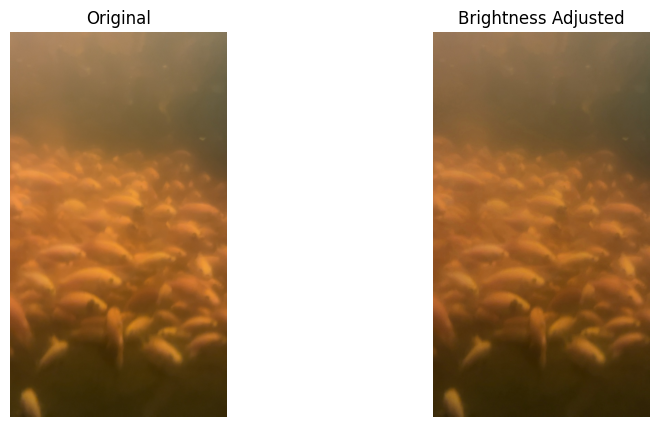

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Set the directory path
directory = '/content/train_Healthy'

# Get a list of all image files in the directory
image_files = [file for file in os.listdir(directory) if file.endswith('.jpg') or file.endswith('.png')]

# Sort the image files
image_files.sort()


# Get the paths for the first and second image
original_img_path = os.path.join(directory, image_files[0])
adjusted_img_path = os.path.join(directory, image_files[1])

# Load the original image
original_img = mpimg.imread(original_img_path)

# Load the brightness-adjusted image
adjusted_img = mpimg.imread(adjusted_img_path)

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Display the original image
axs[0].imshow(original_img)
axs[0].set_title('Original')

# Display the brightness-adjusted image
axs[1].imshow(adjusted_img)
axs[1].set_title('Brightness Adjusted')

# Remove the axes labels
for ax in axs:
    ax.axis('off')

# Show the figure
plt.show()

##Data augmentation: Zoom, cutout, and saturation

Below code implementes the zoom, cutout and saturation data augmentation on 752 randomly selected images each to align the total training data for healthy fish with that of sick fish

In [ ]:
from PIL import Image

# Directory path containing the images
image_dir = '/content/train_Healthy'

# Number of images to select
num_images = 753

# Zoom factor range (1.0 = no zoom)
min_zoom = 1.1
max_zoom = 1.5

# Get a list of image file names from the directory
image_files = os.listdir(image_dir)

# Select random images that end with "score.jpg"
selected_images = [image_file for image_file in image_files if image_file.endswith("score.jpg")]
selected_images = random.sample(selected_images, num_images)

# Process each selected image
for image_file in selected_images:
    # Load the original image
    image_path = os.path.join(image_dir, image_file)
    original_image = Image.open(image_path)

    # Generate a random zoom factor
    zoom_factor = random.uniform(min_zoom, max_zoom)

    # Calculate the new image size
    new_width = int(original_image.width * zoom_factor)
    new_height = int(original_image.height * zoom_factor)

    # Resize the image using the zoom factor
    zoomed_image = original_image.resize((new_width, new_height), Image.BICUBIC)

    # Create a new image with the same proportions as the original
    new_image = Image.new('RGB', original_image.size)

    # Calculate the position to paste the zoomed image in the new image
    paste_x = (new_image.width - zoomed_image.width) // 2
    paste_y = (new_image.height - zoomed_image.height) // 2

    # Paste the zoomed image onto the new image
    new_image.paste(zoomed_image, (paste_x, paste_y))

    # Save the augmented image in the original directory
    augmented_image_path = os.path.join(image_dir, f'{os.path.splitext(image_file)[0]}_zoom.jpg')
    new_image.save(augmented_image_path)

In [ ]:
# Count the number of files in both the healthy and sick dataset
num_files = len([f for f in os.listdir(folder_train_healthy)if os.path.isfile(os.path.join(folder_train_healthy, f))])
print("num of files in train_Healthy/: %d" % (num_files))

num_files = len([f for f in os.listdir(folder_train_sick)if os.path.isfile(os.path.join(folder_train_sick, f))])
print("num of files in train_Sick/: %d" % (num_files))

num of files in train_Healthy/: 4547
num of files in train_Sick/: 6052


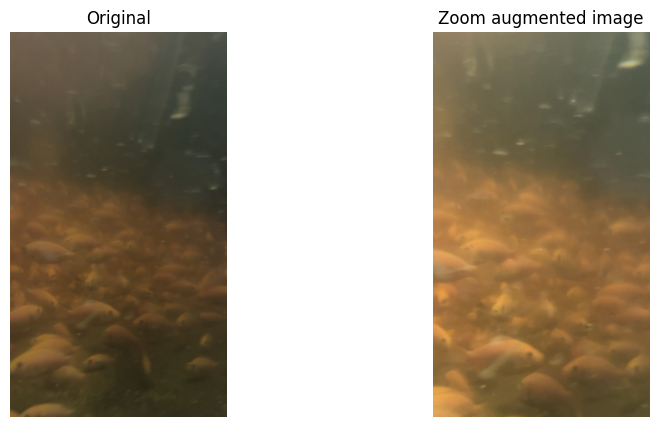

In [ ]:
# Set the directory path
directory = '/content/train_Healthy'

# Get a list of all image files in the directory
image_files = [file for file in os.listdir(directory) if file.endswith('.jpg') or file.endswith('.png')]

# Sort the image files
image_files.sort()

# Find the index of the first image with 'zoom' in its name
zoom_index = next(i for i, file in enumerate(image_files) if 'zoom' in file.lower())

# Get the paths for the original and zoomed image
original_img_path = os.path.join(directory, image_files[zoom_index - 1])
zoomed_img_path = os.path.join(directory, image_files[zoom_index])

# Load the original image
original_img = mpimg.imread(original_img_path)

# Load the zoomed image
zoomed_img = mpimg.imread(zoomed_img_path)

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Display the original image
axs[0].imshow(original_img)
axs[0].set_title('Original')

# Display the zoomed image
axs[1].imshow(zoomed_img)
axs[1].set_title('Zoom augmented image')

# Remove the axes labels
for ax in axs:
    ax.axis('off')

# Show the figure
plt.show()

## Data Augmentation: Cutout

In [ ]:
# Directory path containing the images
image_dir = '/content/train_Healthy'

# Number of images to select
num_images = 752

# Cutout parameters
min_cutout_size = 100  # Minimum size of the cutout region in pixels
max_cutout_size = 200  # Maximum size of the cutout region in pixels

# Get a list of image file names from the directory
image_files = os.listdir(image_dir)

# Select random images ending with "score.jpg"
selected_images = [image_file for image_file in image_files if image_file.endswith("score.jpg")]
selected_images = random.sample(selected_images, num_images)

# Process each selected image
for image_file in selected_images:
    # Load the original image
    image_path = os.path.join(image_dir, image_file)
    original_image = Image.open(image_path)

    # Convert the image to a numpy array
    original_array = np.array(original_image)

    # Get the original image dimensions
    height, width, _ = original_array.shape

    # Generate random coordinates for the cutout region
    x = random.randint(0, width - 1)
    y = random.randint(0, height - 1)

    # Generate random size for the cutout region
    cutout_size = random.randint(min_cutout_size, max_cutout_size)

    # Create a copy of the original image array
    augmented_array = np.copy(original_array)

    # Apply the cutout by setting the region to zero (black)
    augmented_array[max(0, y - cutout_size // 2): min(height, y + cutout_size // 2),
                    max(0, x - cutout_size // 2): min(width, x + cutout_size // 2), :] = 0

    # Create a new image from the augmented array
    augmented_image = Image.fromarray(augmented_array)

    # Save the augmented image in the same directory with "_cutout" appended to the file name
    augmented_image_path = os.path.join(image_dir, f'{os.path.splitext(image_file)[0]}_cutout{os.path.splitext(image_file)[1]}')
    augmented_image.save(augmented_image_path)

In [ ]:
# Count the number of files in both the healthy and sick dataset
num_files = len([f for f in os.listdir(folder_train_healthy)if os.path.isfile(os.path.join(folder_train_healthy, f))])
print("num of files in train_Healthy/: %d" % (num_files))

num_files = len([f for f in os.listdir(folder_train_sick)if os.path.isfile(os.path.join(folder_train_sick, f))])
print("num of files in train_Sick/: %d" % (num_files))

num of files in train_Healthy/: 5299
num of files in train_Sick/: 6052


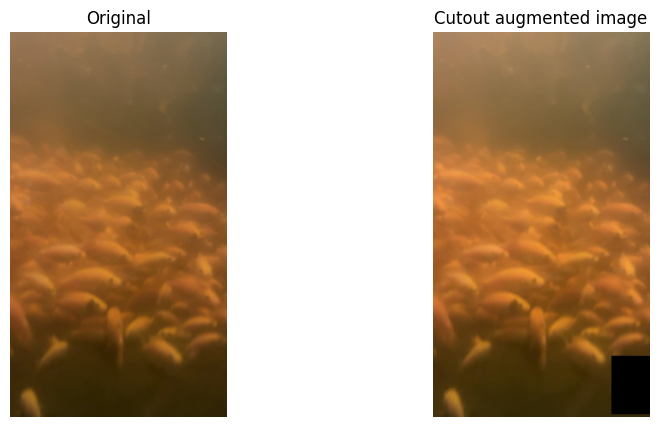

In [ ]:
# Set the directory path
directory = '/content/train_Healthy'

# Get a list of all image files in the directory
image_files = [file for file in os.listdir(directory) if file.endswith('.jpg') or file.endswith('.png')]

# Sort the image files
image_files.sort()

# Find the index of the first image with 'cutout' in its name
cutout_index = next(i for i, file in enumerate(image_files) if 'cutout' in file.lower())

# Get the paths for the original and cutout image
original_img_path = os.path.join(directory, image_files[cutout_index - 1])
cutout_img_path = os.path.join(directory, image_files[cutout_index])

# Load the original image
original_img = mpimg.imread(original_img_path)

# Load the cutout image
cutout_img = mpimg.imread(cutout_img_path)

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Display the original image
axs[0].imshow(original_img)
axs[0].set_title('Original')

# Display the zoomed image
axs[1].imshow(cutout_img)
axs[1].set_title('Cutout augmented image')

# Remove the axes labels
for ax in axs:
    ax.axis('off')

# Show the figure
plt.show()

## Data Augmentation: Saturation

In [ ]:
from PIL import ImageEnhance
import os
import random

# Directory path containing the images
image_dir = '/content/train_Healthy'

# Number of images to select
num_images = 753

# Saturation factor range (1.0 = original saturation, below 1.0 = desaturated, above 1.0 = saturated)
min_saturation_factor = 0.5
max_saturation_factor = 1.5

# Get a list of image file names from the directory
image_files = os.listdir(image_dir)

# Select random images ending with "score.jpg"
selected_images = [image_file for image_file in image_files if image_file.endswith("score.jpg")]
selected_images = random.sample(selected_images, num_images)

# Process each selected image
for image_file in selected_images:
    # Load the original image
    image_path = os.path.join(image_dir, image_file)
    original_image = Image.open(image_path)

    # Generate a random saturation factor
    saturation_factor = random.uniform(min_saturation_factor, max_saturation_factor)

    # Create an enhancer object for saturation
    enhancer = ImageEnhance.Color(original_image)

    # Apply the saturation enhancement
    augmented_image = enhancer.enhance(saturation_factor)

    # Ensure the augmented image has the same proportions as the original
    augmented_image = augmented_image.resize(original_image.size, Image.BICUBIC)

    # Save the augmented image in the same directory with "_saturation" appended to the file name
    augmented_image_path = os.path.join(image_dir, f'{os.path.splitext(image_file)[0]}_saturation{os.path.splitext(image_file)[1]}')
    augmented_image.save(augmented_image_path)

In [ ]:
# Count the number of files in both the healthy and sick dataset
num_files = len([f for f in os.listdir(folder_train_healthy)if os.path.isfile(os.path.join(folder_train_healthy, f))])
print("num of files in train_Healthy/: %d" % (num_files))

num_files = len([f for f in os.listdir(folder_train_sick)if os.path.isfile(os.path.join(folder_train_sick, f))])
print("num of files in train_Sick/: %d" % (num_files))

num of files in train_Healthy/: 6052
num of files in train_Sick/: 6052


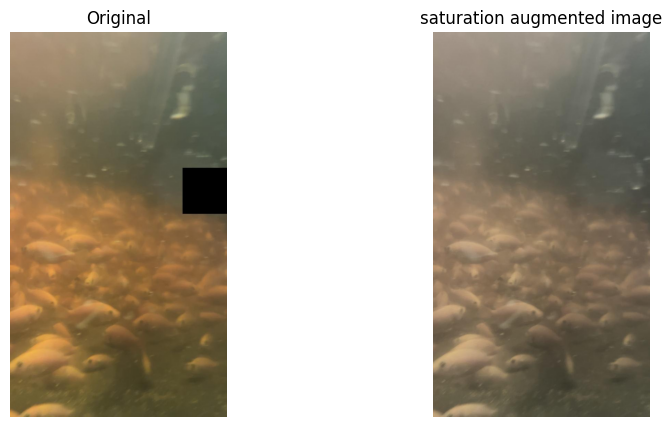

In [ ]:
# Set the directory path
directory = '/content/train_Healthy'

# Get a list of all image files in the directory
image_files = [file for file in os.listdir(directory) if file.endswith('.jpg') or file.endswith('.png')]

# Sort the image files
image_files.sort()

# Find the index of the first image with 'saturation' in its name
saturation_index = next(i for i, file in enumerate(image_files) if 'saturation' in file.lower())

# Get the paths for the original and saturation image
original_img_path = os.path.join(directory, image_files[saturation_index - 1])
saturation_img_path = os.path.join(directory, image_files[saturation_index])

# Load the original image
original_img = mpimg.imread(original_img_path)

# Load the saturation image
saturation_img = mpimg.imread(saturation_img_path)

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Display the original image
axs[0].imshow(original_img)
axs[0].set_title('Original')

# Display the zoomed image
axs[1].imshow(saturation_img)
axs[1].set_title('saturation augmented image')

# Remove the axes labels
for ax in axs:
    ax.axis('off')

# Show the figure
plt.show()

## Data augmentation: Flip in vertical axis

In [ ]:
# Directories containing the images
healthy_dir = '/content/train_Healthy'
sick_dir = '/content/train_Sick'

# Number of new images to create
num_new_images = 1210

# Function to apply horizontal flip and save the augmented image
def apply_horizontal_flip(image_path):
    # Load the original image
    original_image = Image.open(image_path)

    # Apply the horizontal flip
    augmented_image = original_image.transpose(Image.FLIP_LEFT_RIGHT)

    # Save the augmented image in the same directory
    augmented_image_path = os.path.join(os.path.dirname(image_path),
                                        f'{os.path.splitext(os.path.basename(image_path))[0]}_flip{os.path.splitext(os.path.basename(image_path))[1]}')
    augmented_image.save(augmented_image_path)


# Process the 'train_Healthy' directory
healthy_files = os.listdir(healthy_dir)
selected_healthy_images = [image_file for image_file in healthy_files if image_file.endswith("score.jpg")]
num_healthy_images = min(num_new_images, len(selected_healthy_images))

selected_healthy_images = random.sample(selected_healthy_images, num_healthy_images)

for image_file in selected_healthy_images:
    image_path = os.path.join(healthy_dir, image_file)
    apply_horizontal_flip(image_path)


# Process the 'train_Sick' directory
sick_files = os.listdir(sick_dir)
selected_sick_images = [image_file for image_file in sick_files if image_file.endswith("score.jpg")]
num_sick_images = min(num_new_images, len(selected_sick_images))

selected_sick_images = random.sample(selected_sick_images, num_sick_images)

for image_file in selected_sick_images:
    image_path = os.path.join(sick_dir, image_file)
    apply_horizontal_flip(image_path)

In [ ]:
# Count the number of files in both the healthy and sick dataset
num_files = len([f for f in os.listdir(folder_train_healthy)if os.path.isfile(os.path.join(folder_train_healthy, f))])
print("num of files in train_Healthy/: %d" % (num_files))

num_files = len([f for f in os.listdir(folder_train_sick)if os.path.isfile(os.path.join(folder_train_sick, f))])
print("num of files in train_Sick/: %d" % (num_files))

num of files in train_Healthy/: 7262
num of files in train_Sick/: 7262


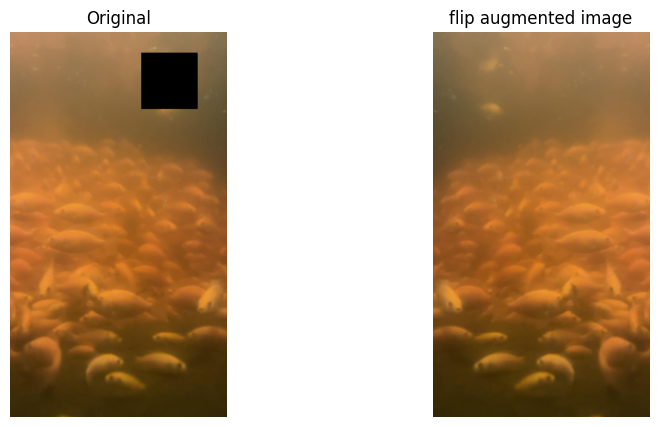

In [ ]:
# Set the directory path
directory = '/content/train_Healthy'

# Get a list of all image files in the directory
image_files = [file for file in os.listdir(directory) if file.endswith('.jpg') or file.endswith('.png')]

# Sort the image files
image_files.sort()

# Find the index of the first image with 'flip' in its name
flip_index = next(i for i, file in enumerate(image_files) if 'flip' in file.lower())

# Get the paths for the original and flip image
original_img_path = os.path.join(directory, image_files[flip_index - 1])
flip_img_path = os.path.join(directory, image_files[flip_index])

# Load the original image
original_img = mpimg.imread(original_img_path)

# Load the flip image
flip_img = mpimg.imread(flip_img_path)

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Display the original image
axs[0].imshow(original_img)
axs[0].set_title('Original')

# Display the zoomed image
axs[1].imshow(flip_img)
axs[1].set_title('flip augmented image')

# Remove the axes labels
for ax in axs:
    ax.axis('off')

# Show the figure
plt.show()

## Data Augmentation: Gaussian noise


In [ ]:
# Directories containing the images
healthy_dir = '/content/train_Healthy'
sick_dir = '/content/train_Sick'

# Percentage of images to select
selection_percentage = 5

# Function to apply Gaussian noise and overwrite the original image
def apply_gaussian_noise(image_path, mean=0, std=0.1):
    # Load the original image
    original_image = Image.open(image_path)

    # Convert the image to a NumPy array
    image_array = np.array(original_image)

    # Generate Gaussian noise with the same shape as the image
    noise = np.random.normal(mean, std, image_array.shape)

    # Add the noise to the image
    augmented_image_array = np.clip(image_array + noise, 0, 255).astype(np.uint8)

    # Create a new Image object from the augmented array
    augmented_image = Image.fromarray(augmented_image_array)

    # Overwrite the original image with the augmented image
    augmented_image.save(image_path)


# Process the 'train_Healthy' directory
healthy_files = os.listdir(healthy_dir)
selected_healthy_images = [image_file for image_file in healthy_files if image_file.endswith("score.jpg")]
num_healthy_images = int(len(selected_healthy_images) * selection_percentage / 100)
selected_healthy_images = random.sample(selected_healthy_images, num_healthy_images)

for image_file in selected_healthy_images:
    image_path = os.path.join(healthy_dir, image_file)
    apply_gaussian_noise(image_path)


# Process the 'train_Sick' directory
sick_files = os.listdir(sick_dir)
selected_sick_images = [image_file for image_file in sick_files if image_file.endswith("score.jpg")]
num_sick_images = int(len(selected_sick_images) * selection_percentage / 100)
selected_sick_images = random.sample(selected_sick_images, num_sick_images)

for image_file in selected_sick_images:
    image_path = os.path.join(sick_dir, image_file)
    apply_gaussian_noise(image_path)

In [ ]:
# Count the number of files in both the healthy and sick dataset
num_files = len([f for f in os.listdir(folder_train_healthy)if os.path.isfile(os.path.join(folder_train_healthy, f))])
print("num of files in train_Healthy/: %d" % (num_files))

num_files = len([f for f in os.listdir(folder_train_sick)if os.path.isfile(os.path.join(folder_train_sick, f))])
print("num of files in train_Sick/: %d" % (num_files))

num of files in train_Healthy/: 7262
num of files in train_Sick/: 7262


# Data Folder split

In [ ]:
import shutil

# Source directories
healthy_source_dir = '/content/train_Healthy'
sick_source_dir = '/content/train_Sick'
healthy_source_dir_val = '/content/validation_Healthy'
sick_source_dir_val = '/content/validation_Sick'
healthy_source_dir_test = '/content/test_Healthy'
sick_source_dir_test = '/content/test_Sick'

# Destination directory
destination_dir = '/content/total_training'
destination_dir_val = '/content/total_validation'
destination_dir_test = '/content/total_test'

# Copy 'train_Healthy' directory
shutil.copytree(healthy_source_dir, destination_dir + '/train_Healthy')
shutil.copytree(healthy_source_dir_val, destination_dir_val + '/validation_Healthy')
shutil.copytree(healthy_source_dir_test, destination_dir_test + '/test_Healthy')
# Copy 'train_Sick' directory
shutil.copytree(sick_source_dir, destination_dir + '/train_Sick')
shutil.copytree(sick_source_dir_val, destination_dir_val + '/validation_Sick')
shutil.copytree(sick_source_dir_test, destination_dir_test + '/test_Sick')

'/content/total_test/test_Sick'

# Convolutional Neural Network


Below is the code for the creation, training, validation and testing of the Convolutional Neural Networks for the prediction of disease in Nile tilapia.

In the first cell we build the architecture of the model and plot this for visualisation


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 1119, 629, 16)     208       
                                                                 
 batch_normalization_6 (Batc  (None, 1119, 629, 16)    64        
 hNormalization)                                                 
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 559, 314, 16)     0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 558, 313, 32)      2080      
                                                                 
 batch_normalization_7 (Batc  (None, 558, 313, 32)     128       
 hNormalization)                                                 
                                                      

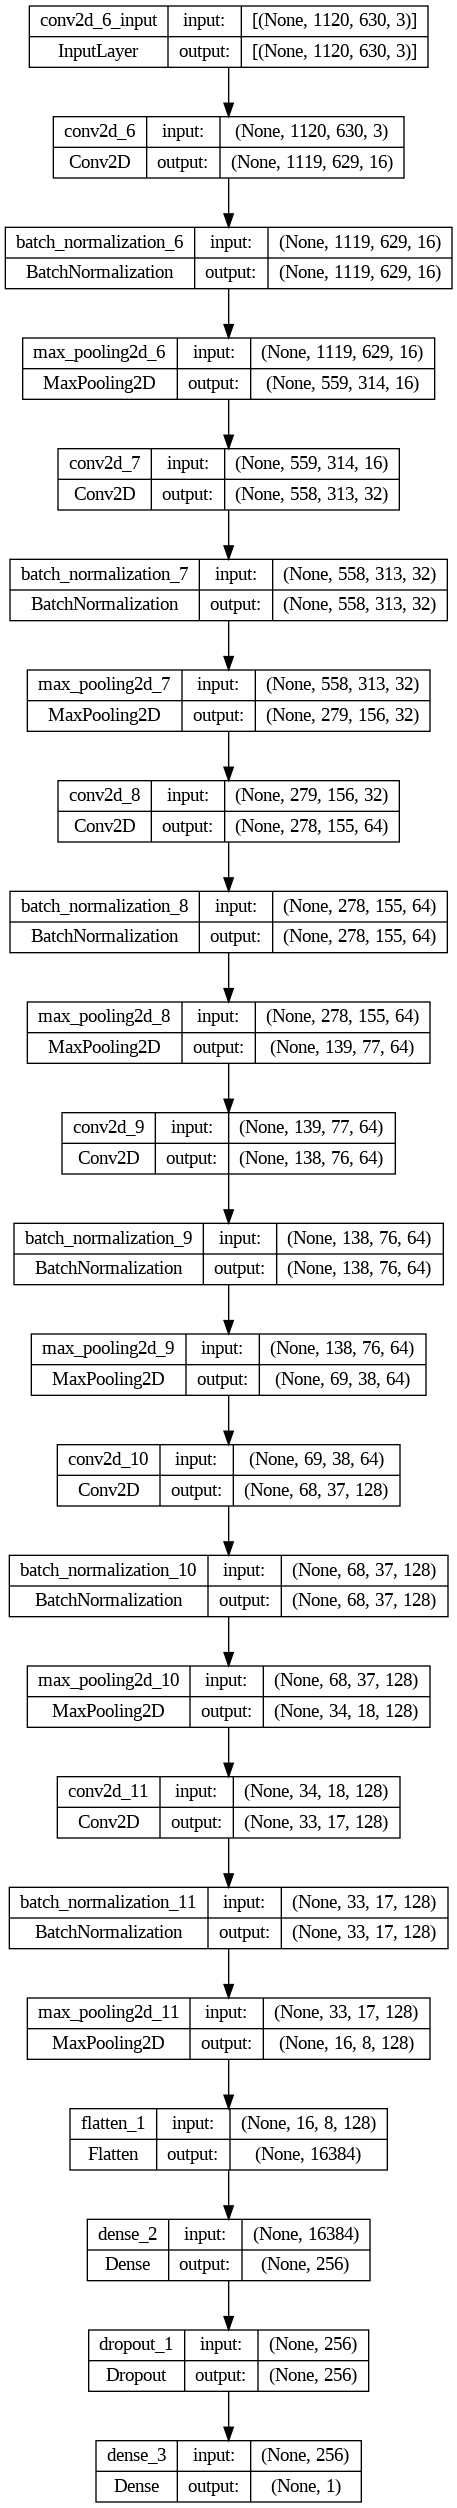

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, BatchNormalization, Flatten, Dropout
from keras.utils import plot_model

model = Sequential()

#Layer 1
model.add(Conv2D(16, (2, 2), activation='relu', input_shape=(height_picture, width_picture, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

#Layer 2
model.add(Conv2D(32, (2, 2), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

#Layer 3
model.add(Conv2D(64, (2, 2), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

#Layer 4
model.add(Conv2D(64, (2, 2), activation='relu')) #change back to 64
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

#Layer 5
model.add(Conv2D(128, (2, 2), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

#Layer 6
model.add(Conv2D(128, (2, 2), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())

#Final layer
model.add(Dense(256, activation='relu')) #was 256
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.summary()

# Plotting shape of CNN
plot_model(model, show_shapes=True)

## Model Compilation testing

Below is the cell for compiling the base model. Only this cell needs to be run from this section

In [ ]:
# Binary_crossentropy used for a binary classification
model.compile(loss='binary_crossentropy',
            optimizer='adam',
            metrics=['accuracy'])

###Alternative models

Below are cells for altering the values used to compile the model including the learning rates, loss function and opimiser

#### (ID 13 and 14) High or Low learning rate model

Starting with defining the learning rate variables for use in the high and low learning rate model

In [ ]:
from keras.optimizers import Adam

# Compile the model with different learning rates
learning_rate_high = 0.001  # Higher learning rate
learning_rate_low = 0.0001  # Lower learning rate

High learning rate model compilation

In [ ]:
# Compile model with higher learning rate
optimizer_high_lr = Adam(learning_rate=learning_rate_high)
model_high_lr = model
model.compile(loss='binary_crossentropy',
              optimizer=optimizer_high_lr,
              metrics=['accuracy'])

Low learning rate model compilation

In [ ]:
# Compile model with lower learning rate
optimizer_low_lr = Adam(learning_rate=learning_rate_low)
model.compile(loss='binary_crossentropy',
              optimizer=optimizer_low_lr,
              metrics=['accuracy'])

####(ID 11 and 12) SGD with Hinge loss OR RMSProp with KLDivergence

RMSProp + KLDivergence


In [ ]:
from keras.optimizers import RMSprop
from keras.losses import KLDivergence

# Compile the model with RMSprop optimizer and KL Divergence loss
model.compile(loss=KLDivergence(),
              optimizer=RMSprop(learning_rate=0.001),
              metrics=['accuracy'])

SGD + Hinge loss

In [ ]:
from keras.optimizers import SGD
from keras.losses import Hinge

# Compile the model with SGD optimizer and Hinge loss
model.compile(loss=Hinge(),
              optimizer=SGD(learning_rate=0.01, momentum=0.9),
              metrics=['accuracy'])

## Model training and saving

The weights of the initialised model are saved so that these can be used to reset the weights and try variations in training

In [ ]:
model_folder = '/content/gdrive/MyDrive/Colab Notebooks/models'

os.makedirs(model_folder, exist_ok=True)
model.save(model_folder+'model_initial_weights_september_2023_self_train.h5')

The below cell performs the data preprocessing in the form of rescalling pixel values in the range [0, 255] to [0, 1]. Furthermore the batch size for training is set and a train and validation generator are created to load and preprocess images from the specified directories

In [ ]:
from keras.preprocessing.image import ImageDataGenerator

train_dir = '/content/total_training'
validation_dir = '/content/total_validation'

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


batch_size = 32 #was 32
# This is a generator that will read pictures found in the training data folder
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (height_picture, width_picture),
    batch_size=batch_size,
    class_mode='binary')

# This is a generator that will read pictures found in the validation data folder
val_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size = (height_picture, width_picture),
    batch_size=batch_size,
    class_mode='binary')

Found 14524 images belonging to 2 classes.
Found 1828 images belonging to 2 classes.


The code below trains the model and is also where the epoch hyperparameter is set. The steps per epoch are set at half the data.

Code is included for the implementation of Early stopping but this is commented out in the current iteration

In [ ]:
from keras.callbacks import EarlyStopping

total_train_samples = 7262 + 7262 # was 7262
total_val_samples = 790 + 1038  # Total number of validation samples


# Calculate the number of steps per epoch
steps_per_epoch = total_train_samples // batch_size

# Calculate the number of validation steps
validation_steps = total_val_samples // batch_size

n_train_per_class = 7262 # number of training images in both classes
n_val_per_class = 790 # number of validation images in both classes

# Define the early stopping callback
# early_stopping = EarlyStopping(monitor='val_loss', patience=5)

history = model.fit_generator(
    train_generator,
    steps_per_epoch=n_train_per_class * 2 // (batch_size * 2),
    epochs= 10,
    validation_data=val_generator,
    validation_steps=n_val_per_class * 2 // (batch_size * 2)
)

<ipython-input-42-84a8a4fee753>:19: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(


Epoch 1/10
226/226 [==============================] - 161s 708ms/step - loss: 0.6532 - accuracy: 0.8462 - val_loss: 0.6980 - val_accuracy: 0.7799
Epoch 2/10
226/226 [==============================] - 157s 694ms/step - loss: 0.5762 - accuracy: 0.9240 - val_loss: 0.9967 - val_accuracy: 0.4336
Epoch 3/10
226/226 [==============================] - 157s 692ms/step - loss: 0.5630 - accuracy: 0.9367 - val_loss: 0.8716 - val_accuracy: 0.5586
Epoch 4/10
226/226 [==============================] - 156s 690ms/step - loss: 0.5526 - accuracy: 0.9467 - val_loss: 0.9062 - val_accuracy: 0.5469
Epoch 5/10
226/226 [==============================] - 156s 690ms/step - loss: 0.5415 - accuracy: 0.9556 - val_loss: 0.4899 - val_accuracy: 0.9453
Epoch 6/10
226/226 [==============================] - 155s 687ms/step - loss: 0.5419 - accuracy: 0.9578 - val_loss: 0.7223 - val_accuracy: 0.7044
Epoch 7/10
226/226 [==============================] - 158s 696ms/step - loss: 0.5352 - accuracy: 0.9636 - val_loss: 0.6168 -

The below cell allows for the saving of the newly trained weights

In [ ]:
model_folder = '/content/gdrive/MyDrive/Colab Notebooks/models'

os.makedirs(model_folder, exist_ok=True)
model.save(model_folder+'/tilapia_disease_batch_normalisation_10_epochs_4_3_mil_param_226_steps_per_epoch_ID_11.h5')  # always save your model after training


Next we graph the results of the trained model. This code plots the training and validation loss as well as the training and validation accuracy

Text(0.5, 0, 'epoch')

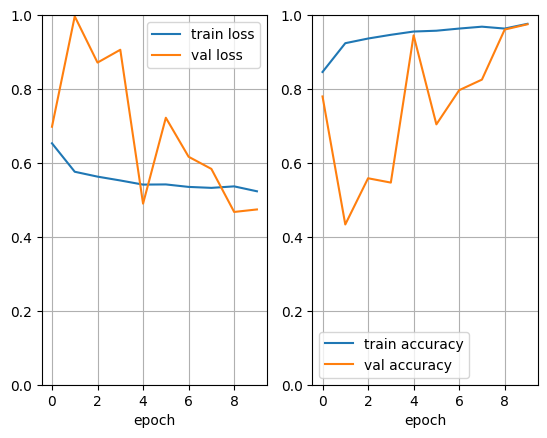

In [ ]:
# plot the learning curves
import matplotlib.pyplot as plt
fig = plt.figure()
fig.add_subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.grid(True)
plt.ylim([0,1.0])
plt.xlabel('epoch')

fig.add_subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0,1.0])
plt.xlabel('epoch')

Testing the trained model against the not-seen-before test data is done with the below code. The results are given between 0 and 1 and indicate how accurately the model classifies images both sick and healthy.

The value can be multiplied by 100 to get the percentage accuracy

In [ ]:
test_dir = '/content/total_test'

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (height_picture, width_picture),
    batch_size = batch_size,
    class_mode = 'binary'
)

n_test_per_class = 476


test_loss, test_acc = model.evaluate(test_generator, steps=n_test_per_class*2 // batch_size)
print('Test accuracy: ', test_acc)


Found 952 images belonging to 2 classes.
29/29 [==============================] - 18s 628ms/step - loss: 0.5209 - accuracy: 0.9806
Test accuracy:  0.9806034564971924


# Loading model weights

The below cells allows for the loading of weights. Mostly used for loading in the initialisation weights of the model

In [ ]:
# Load the weights from a pre-saved file
#model.load_weights('/content/gdrive/MyDrive/Colab Notebooks/models/tilapia_disease_800pixel_GPU_training.h5')
model_folder = '/content/gdrive/MyDrive/Colab Notebooks/models'
model.load_weights(model_folder+'/tilapia_disease_batch_normalisation_4_epochs_4_3_mil_param_226_steps_per_epoch_high_learning_rate.h5')

# Pre-trained Resnet18

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torch.optim as optim

# Lists that will hold values for plotting accuracy and losses
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# ResNet18 custom CNN with custom classification head (self.fc)
# This adapts the original network for the binary classification task
class ResNet18CustomInput(nn.Module):
    def __init__(self, num_classes):
        super(ResNet18CustomInput, self).__init__()
        resnet = models.resnet18(pretrained=True)
        modules = list(resnet.children())[:-1]

        self.features = nn.Sequential(*modules)
        self.fc = nn.Linear(resnet.fc.in_features, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


# Set training, validation and testing directories in case code was not run in previous cells
train_dir = '/content/total_training'
valid_dir = '/content/total_validation'
test_dir = '/content/total_test'

# Binary classification so classes is equal to 2
num_classes = 2

# Batch size variable
batch_size = 16 # was 32

# Data transformations for Resnet model including:
# Tranforming the image to a pytorch tensor
# Normalising input data to have mean of 0 and standard deviation of 1 in every channel
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load all the data for training, validation and testing
train_data = ImageFolder(train_dir, transform=transform)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

valid_data = ImageFolder(valid_dir, transform=transform)
valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=False)

test_data = ImageFolder(test_dir, transform=transform)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# Instantiate the model
model = ResNet18CustomInput(num_classes)

# Freeze all layers except the last two
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

# Define the loss function
criterion = nn.CrossEntropyLoss()
#criterion = nn.MultiMarginLoss()  # Hinge loss

# Define the optimizer
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001) #was 0.001 for high learning rate
#optimizer = optim.SGD(model.fc.parameters(), lr=0.001)

# Set the epochs here
num_epochs = 8
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct_train = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        # Get the predicted labels
        _, preds = torch.max(outputs, 1)
        # Update count for correct_train
        correct_train += torch.sum(preds == labels.data)

    train_loss /= len(train_loader.dataset)  # Divide by total number of training samples
    train_accuracy = correct_train.double() / len(train_loader.dataset)


    # Validation
    model.eval()
    valid_loss = 0.0 #Code change in flight
    val_loss = 0.0
    correct_val = 0.0

    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            valid_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct_val += torch.sum(preds == labels.data)

        val_loss = valid_loss / len(valid_loader.dataset) #code changed flight
        val_accuracy = correct_val.double() / len(valid_loader.dataset)

        # Append validation loss to list
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy.item())

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy.item())

    print(f"Epoch {epoch+1}/{num_epochs}:")
    print(f"  Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f}")
    print(f"  Valid Loss: {val_loss:.4f} | Valid Accuracy: {val_accuracy:.4f}")

    print(f"Epoch {epoch+1}/{num_epochs}:")


Epoch 1/8:
  Train Loss: 0.3438 | Train Accuracy: 0.8529
  Valid Loss: 0.2583 | Valid Accuracy: 0.9092
Epoch 1/8:
Epoch 2/8:
  Train Loss: 0.2335 | Train Accuracy: 0.9071
  Valid Loss: 0.2014 | Valid Accuracy: 0.9333
Epoch 2/8:
Epoch 3/8:
  Train Loss: 0.2079 | Train Accuracy: 0.9199
  Valid Loss: 0.1708 | Valid Accuracy: 0.9486
Epoch 3/8:
Epoch 4/8:
  Train Loss: 0.2002 | Train Accuracy: 0.9215
  Valid Loss: 0.1932 | Valid Accuracy: 0.9283
Epoch 4/8:
Epoch 5/8:
  Train Loss: 0.1815 | Train Accuracy: 0.9310
  Valid Loss: 0.1396 | Valid Accuracy: 0.9568
Epoch 5/8:
Epoch 6/8:
  Train Loss: 0.1808 | Train Accuracy: 0.9298
  Valid Loss: 0.1319 | Valid Accuracy: 0.9573
Epoch 6/8:
Epoch 7/8:
  Train Loss: 0.1719 | Train Accuracy: 0.9340
  Valid Loss: 0.1310 | Valid Accuracy: 0.9601
Epoch 7/8:
Epoch 8/8:
  Train Loss: 0.1634 | Train Accuracy: 0.9375
  Valid Loss: 0.1263 | Valid Accuracy: 0.9573
Epoch 8/8:


Similar to the self-trained CNN we plot the train and validation accuracy and loss

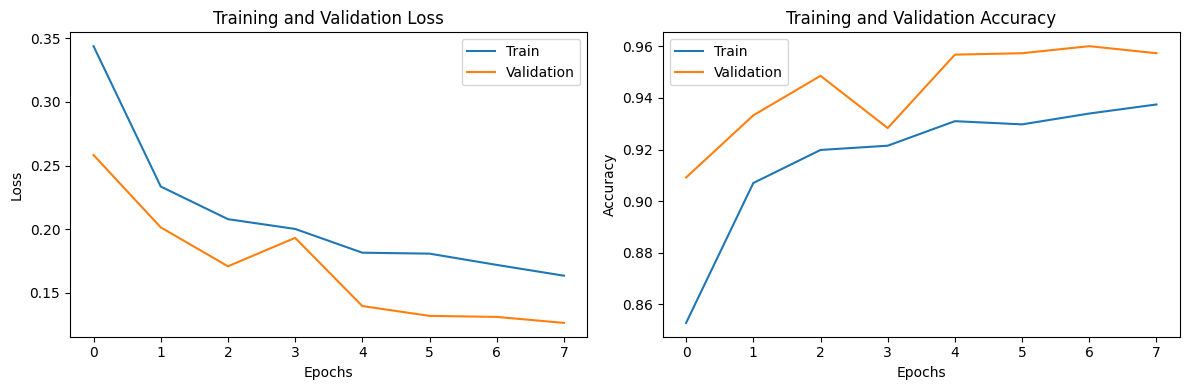

In [ ]:
import matplotlib.pyplot as plt

# Plotting
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train')
plt.plot(val_accuracies, label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.tight_layout()
plt.show()

Save the newly trained weights

In [ ]:
# Save the model weights
save_path = '/content/gdrive/MyDrive/Colab Notebooks/models/resnet18_weights_10_epochs_0_001lr_32_batches_highest_performer.pth'
torch.save(model.state_dict(), save_path)
print(f"Model weights saved at: {save_path}")

Model weights saved at: /content/gdrive/MyDrive/Colab Notebooks/models/resnet18_weights_10_epochs_0_001lr_32_batches_highest_performer.pth


Test the ability for the ResNet-18 model to generalise over not-before-seen data. Final value can be multiplied by 100 for a percentage

In [ ]:
# Testing loop
model.eval()
test_loss = 0.0
test_accuracy = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        test_accuracy += torch.sum(preds == labels.data)

test_loss /= len(test_data)
test_accuracy = test_accuracy.double() / len(test_data)

print("Test Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy:.4f}")

Test Results:
  Loss: 0.1396
  Accuracy: 0.9475


## Notebook clean up code

Below are code cells used to produce a clean-up of data

In [ ]:
# Used for removing any pictures with 'brightness' in their title
# These images are generated from code with a random factor for brightness adjustment

#folder_path = '/content/train_Healthy'

#for filename in os.listdir(folder_path):
#    file_path = os.path.join(folder_path, filename)
#    if os.path.isfile(file_path) and "flip" in filename:
#        os.remove(file_path)

#zoom, cutout, contrast

In [ ]:
#directory_to_delete = '/content/total_validation'

# Delete the directory and its contents
#shutil.rmtree(directory_to_delete)

In [ ]:
# Sharpening all images in the dataset might be useful -> Underwater Fish Species Recognition using Deep Learning Techniques
# Make changes to datasets so all testing have the same size, make up difference with augmentation


Resnet-18 weight reset code

In [ ]:
#Reset resnet18 weights

import torch
import torchvision.models as models

# Set the number of classes
num_classes = 2  # Number of possible outcomes

# Instantiate the model with pretrained weights
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, num_classes)

# Reset the model to its initial weights
def reset_model_to_initial_weights(model):
    for module in model.modules():
        if isinstance(module, torch.nn.Conv2d) or isinstance(module, torch.nn.Linear):
            module.reset_parameters()

# Call the function to reset the model
reset_model_to_initial_weights(model)

# Print the model architecture
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  